# Table of Contents
* [Context](#context)
* [Dataset exploratory analysis](#exploration)
    * [Obtain the dataset](#obtain)
    * [Dataset structure](#structure)
    * [Dataset images in detail](#images)
* [Implementation](#implementation)
    * [Preprocessing](#preprocessing)
    * [Experiments](#experiments)
* [Results](#result)

## Context <a class="anchor" id="context"></a>
This notebook implements the experiments proposed on [my Msc. thesis](https://github.com/EstherRH00/TDA_Visual_Transformer/blob/main/TFM.pdf) and aims to answer the following hypothesis:

**H1:** Image preprocessing techniques (noise reduction and contrast enhancement) positively impact the classification accuracy of a Vision Transformer model.

**H2:** : The incorporation of topological descriptors derived from TDA provides complementary structural information that improves classification performance compared to a standard Vision Transformer.

To do so, it uses the mamographies from the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/), the [base-sized Visual transformer](https://huggingface.co/google/vit-base-patch16-224) and the [Gudhy library](https://gudhi.inria.fr/python/latest/) to extract topological descriptors, as well as pytorch and other python libraries.

The project structure is:


```
.
├── data                    <- Images
│   ├── raw                 <- Dataset images in dcm format
│   ├── raw_np              <- Dataset images in np format
│   ├── tda                 <- Topological descriptors of the images
│   └── preprocessed        <- Preprocessed images  
├── src
│   ├── datasets            <- Implements torch.dataset
│   ├── models              <- Implements nn.Module for the ViT and ViT + TDA
│   ├── tda                 <- To compute topological descriptors
│   ├── training            <- To train and evaluate the model
│   └── utils               <- Image processing utils
├── checkpoints             <- Experiment results
│   └── ...
├── .gitignore
├── notebook.ipynb          <- This notebook 
├── notebook.html
├── README.md
├── requirements.txt   
└── TFM.pdf                 <- Msc. Thesis
```

Each of the following sections guides the project step by step. 



## Dataset exploratory analysis <a id="exploration"></a>
This section introduces the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) and its structure.

The CBIS-DDSM (Curated Breast Imaging Subset of DDSM dataset) provides three types of images of two kinds of two types of lessions (breast masses and breast calcifications), and classifies them as Benign, Benign without a callback or Malign. In this project, Benign without a callback is considered the same as Bening as a simplification, as the difference is wether the radiologist required more images to confirm the result or not. There are 1`,`566 participants, and 10,239 images in 6,775 series, as for one patient id (encoded as P_<5 digit number>) there can be multiple scans performed.

It separates them into training and testing groups by patient:
* Breast masses:
  * Training set: 691 subjects (77.5%)
  * Testing set: 201 subjects (22.5%)
* Breast calcifications:
  * Training set: 602 subjects (79.9%)
  * Testing set: 151 subjects (20.1%)

This project uses these same partitions, and extracts a validation subgroup from the training set.

For each lesion studied, it provides 3 images:
1. The full mamography.
2. A region of interest (ROI) mask, that can be applied to the mamography
3. A ROI crop of the mamography, that is a rectangular crop containing the ROI.

### Obtain the dataset <a id="obtain"></a>
To download the dataset, the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) webpage proportionates four csv files and a `.tcia` file. That file is used to download the images using the [TCIA image retirever](https://wiki.cancerimagingarchive.net/display/NBIA/Downloading+TCIA+Images), that is a program that you will need to install. Image retrieval for this dataset took about 8hrs, so it is recomended to do so overnight. Once the images are downloaded, the `data` folder will be populated like so:

```
.
├── data
│   ├── raw
│   |   ├── cbis_ddsm
│   |   |   ├── Calc-Test_...
│   |   |   |   └── <numerical_id>
│   |   |   |       └── <numerical_id>
│   |   |   |           ├── <numerical_id>.dcm
│   |   |   |           └── <numerical_id>.dcm
│   |   |   ├── ...
│   |   |   ├── Calc-Training_...
│   |   |   ├── ...
│   |   |   ├── Mass-Test_...
│   |   |   ├── ...
│   |   |   ├── Mass-Training_...
│   |   |   ├── ...
│   |   |   ├── P_....dcm
│   |   |   ├── ...
│   |   |   └── metadata.csv
│   |   ├── metadata
│   |   |   └── metadata.csv
│   |   ├── calc_case_description_test_set.csv
│   |   ├── calc_case_description_train_set.csv
│   |   ├── mass_case_description_test_set.csv
│   |   └── mass_case_description_train_set.csv
│   ├── raw_np
│   ├── tda
│   └── preprocessed
└── ...
```

### Dataset structure <a id="structure"></a>
First, we explore the csv files:


In [2]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [2]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [3]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


The mass and calc datasets have very similar columns, whilst the metadata one just keeps a download log, so it is not relevant to this project. The mass and calc datasets have the following columns:

#### Breast calcifications
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `calc type`: type of calcification; some of the possible values are 'AMORPHOUS','PLEOMORPHIC', nan 'ROUND_AND_REGULAR-LUCENT_CENTER-DYSTROPHIC', PUNCTATE', 'COARSE', 'VASCULAR', etc.
* `calc distribution`: distribution of the calcification, with 10 possible values: 'CLUSTERED', 'LINEAR','REGIONAL', 'DIFFUSELY_SCATTERED','SEGMENTAL',nan,'CLUSTERED-LINEAR', 'CLUSTERED-SEGMENTAL',    'LINEAR-SEGMENTAL' and 'REGIONAL-REGIONAL'.
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mamography.
* `cropped image file path`: file path of the cropped mamography.
* `ROI mask file path`: file path of the ROI mask.

#### Breast masses
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `mass shape`: shape of the mass, it can take 19 different values, that contain 'IRREGULAR-ARCHITECTURAL_DISTORTION', 'ARCHITECTURAL_DISTORTION', 'OVAL', 'IRREGULAR', 'LYMPH_NODE',etc.
* `mass margins`: type of margin, it can take 16 different values that contain: 'SPICULATED', 'ILL_DEFINED', 'CIRCUMSCRIBED', 'ILL_DEFINED-SPICULATED', 'OBSCURED',
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mamography.
* `cropped image file path`: file path of the cropped mamography.
* `ROI mask file path`: file path of the ROI mask.

While exploring the dataset, I found a peculiarity about the paths:
1. The name of the `.dcm` files is wrong: the csv files give the images names that are either `00000.dcm` or `00001.dcm`, but when exploring the paths, the images found have names that follow this structure: `9587fd8e-e6d7-4de0-83c8-d945c6f5330c`.
2. Most of the times, the ROI mask and the cropped image share folder, which combined with the issue described above, can cause confusion.

The following code cell explores this problem.


In [4]:
import numpy as np
import os
from src.utils.image_utils import get_all_dcm_files_with_size

def extract_folder(path):
    return os.path.dirname(path.strip())

print("===============================")
print("PROBLEM 1: NAMES NOT MATCHING")

print("Names provided by the CSV")
print("Image path:\t\t", mass_train_df['image file path'][0])
print("Cropped image path:\t",mass_train_df['cropped image file path'][0])
print("ROI mask path:\t\t",mass_train_df['ROI mask file path'][0])

print("Files in that folder provided by the CSV")
print("Image path:\t\t", get_all_dcm_files_with_size(mass_train_df['image file path'][0]))
print("Cropped image path:\t", get_all_dcm_files_with_size(mass_train_df['cropped image file path'][0]))
print("ROI mask path:\t\t", get_all_dcm_files_with_size(mass_train_df['ROI mask file path'][0]))


print("\n===============================")
print("PROBLEM 2: ROI MASK AND CROPPED IMAGE SHARING FOLDER")
print("Amount of rows where the mask and cropped image have different paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) != mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])
print("Amount of rows where the mask and cropped image have the same paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) == mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])


PROBLEM 1: NAMES NOT MATCHING
Names provided by the CSV
Image path:		 Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Cropped image path:	 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000000.dcm
ROI mask path:		 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000001.dcm

Files in that folder provided by the CSV
Image path:		 [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00001_LEFT_CC\\1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994\\1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515\\e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm', 29079880)]
Cropped

To solve these issues, we observe that the ROI mask has a bigger size than the cropped image, as it is a mask for the full image and contains way more pixels. Since the file names in the csv are not the real ones, the size difference will be used to differenciate them.


### Dataset images in detail <a id="images"></a>

The full mamography, cropped image, ROI mask and ROI mask applied to the mamography of the first Breast Mass of the dataset:

<Figure size 1000x1000 with 0 Axes>

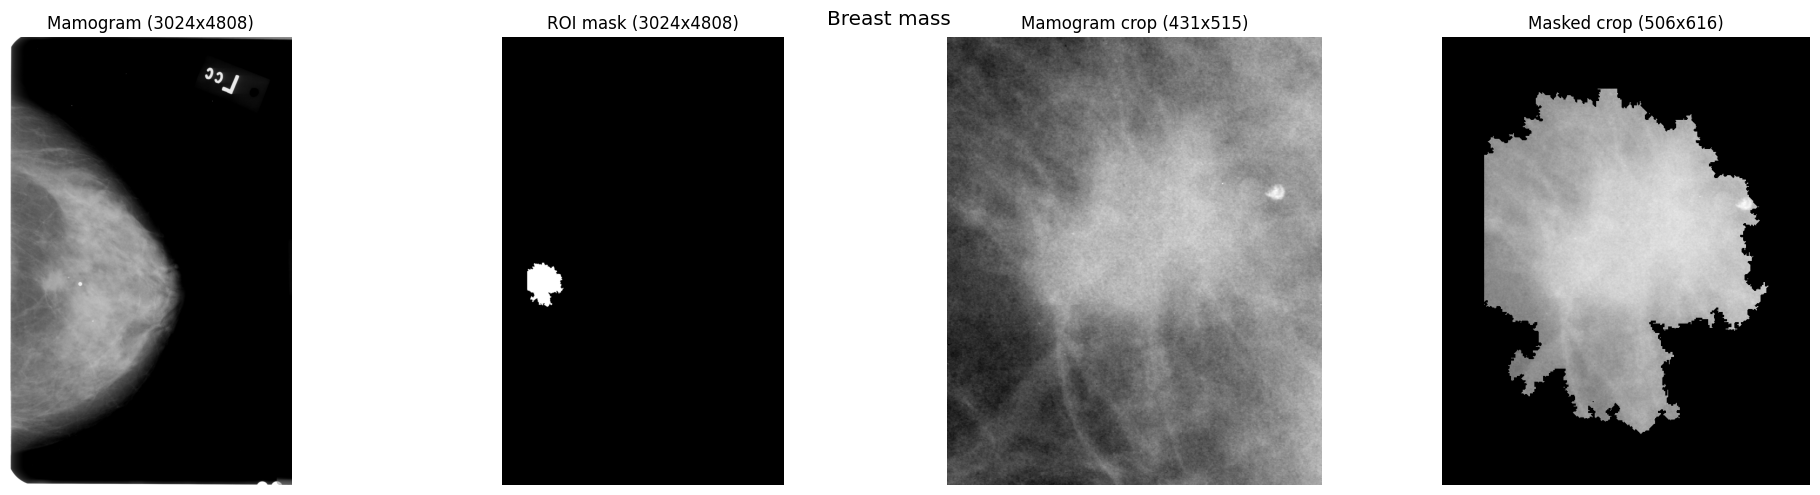

In [5]:
import matplotlib.pyplot as plt
from src.utils.image_utils import resolve_mamogram_path, resolve_cropped_mamogram_path, resolve_roi_mask_path, load_dicom, extract_roi_crop

row = mass_train_df.iloc[0]

mamogram_path = resolve_mamogram_path(row["image file path"])
mamogram = load_dicom(mamogram_path)

roi_mask_path = resolve_roi_mask_path(row["ROI mask file path"])
roi_mask = load_dicom(roi_mask_path)

cropped_mamogram_path = resolve_cropped_mamogram_path(row["cropped image file path"])
cropped_mamogram = load_dicom(cropped_mamogram_path)

roi_crop, masked_crop = extract_roi_crop(mamogram, roi_mask)

plt.figure(figsize=(10,10))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(axes,
    [mamogram, roi_mask, cropped_mamogram, masked_crop],
    [f'Mamogram ({mamogram.shape[1]}x{mamogram.shape[0]})',
     f'ROI mask ({roi_mask.shape[1]}x{roi_mask.shape[0]})',
     f'Mamogram crop ({cropped_mamogram.shape[1]}x{cropped_mamogram.shape[0]})',
     f'Masked crop ({masked_crop.shape[1]}x{masked_crop.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.suptitle("Breast mass", fontsize="x-large")
plt.show()

The full mamography, cropped image, ROI mask and ROI mask applied to the mamography of the first Breast Calcification of the dataset:

<Figure size 1000x1000 with 0 Axes>

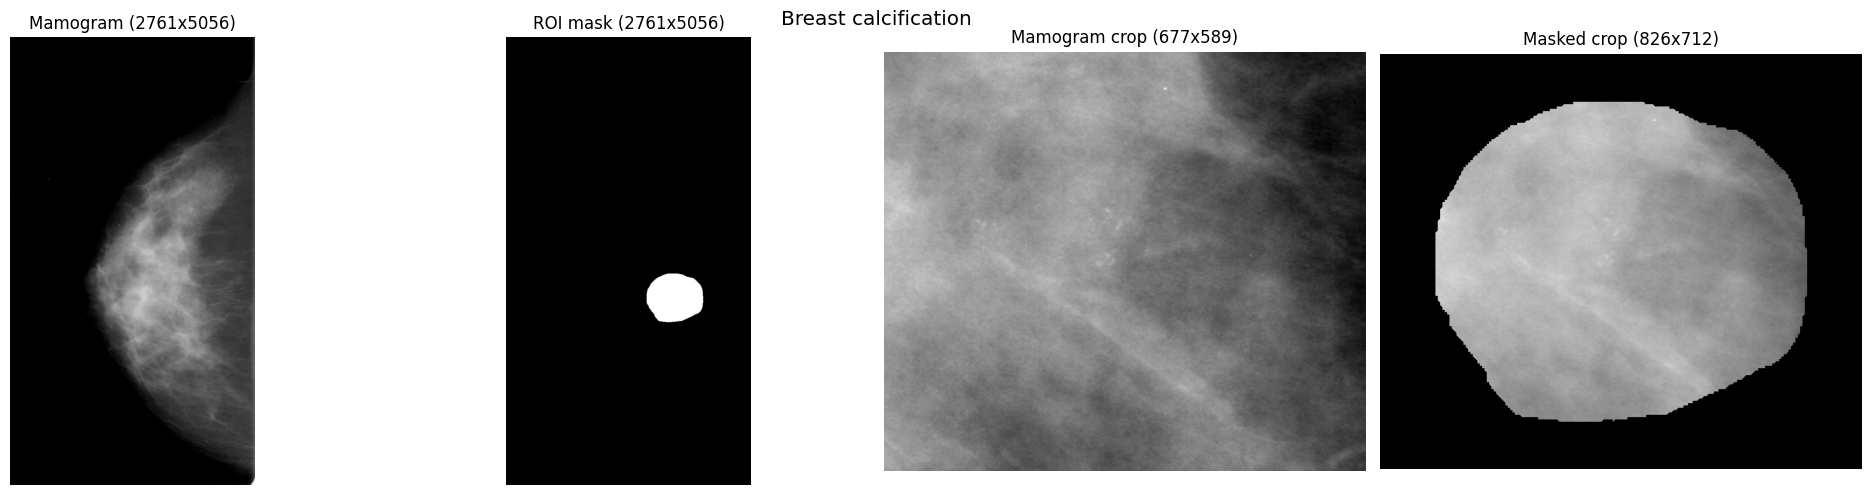

In [6]:
row = calc_train_df.iloc[0]

mamogram_path = resolve_mamogram_path(row["image file path"])
mamogram = load_dicom(mamogram_path)

roi_mask_path = resolve_roi_mask_path(row["ROI mask file path"])
roi_mask = load_dicom(roi_mask_path)

cropped_mamogram_path = resolve_cropped_mamogram_path(row["cropped image file path"])
cropped_mamogram = load_dicom(cropped_mamogram_path)

roi_crop, masked_crop = extract_roi_crop(mamogram, roi_mask)

plt.figure(figsize=(10,10))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(axes,
    [mamogram, roi_mask, cropped_mamogram, masked_crop],
    [f'Mamogram ({mamogram.shape[1]}x{mamogram.shape[0]})',
     f'ROI mask ({roi_mask.shape[1]}x{roi_mask.shape[0]})',
     f'Mamogram crop ({cropped_mamogram.shape[1]}x{cropped_mamogram.shape[0]})',
     f'Masked crop ({masked_crop.shape[1]}x{masked_crop.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()

plt.suptitle("Breast calcification", fontsize="x-large")
plt.show()

TODO: 
* WRITE WHY WE DO MASS ONLY
* WRITE WHERE WE USE CROPPED IMAGE
* WRITE WHERE WE USE MASKED CROP

## Implementation <a id="implementation"></a>

TODO: WRITE

### Preprocessing <a id="preprocessing"></a>

TODO: WRITE

In [8]:
MASS_TRAIN_SAVE_DIR = "data/raw_np/mass_train"
MASS_TEST_SAVE_DIR = "data/raw_np/mass_test"

In [ ]:
from src.utils.image_utils import cache_cropped_images_as_np_arrays

cache_cropped_images_as_np_arrays(MASS_TRAIN_SAVE_DIR, mass_train_df)
cache_cropped_images_as_np_arrays(MASS_TEST_SAVE_DIR, mass_test_df)

1318it [00:04, 310.27it/s]
378it [00:01, 301.21it/s]


In [1]:

import numpy as np
import random

SEED = 2
np.random.seed(SEED)
random.seed(SEED)

### Experiments <a id="experiments"></a>

TODO: WRITE

In [ ]:
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

# Load the cached pre-cropped lesion paths from Step 1
train_cache = pd.read_csv(MASS_TRAIN_SAVE_DIR + '/cached.csv')
test_cache = pd.read_csv(MASS_TEST_SAVE_DIR + '/cached.csv')

results = {}

# --- E1: ViT baseline (no preprocessing, no TDA) ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=False, augment=False)

results['E1'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E1: ViT baseline ===
  [E1] Epoch 1/30  train_loss=0.7776  val_loss=0.7135  val_auc=0.5826
  [E1] Epoch 2/30  train_loss=0.7526  val_loss=0.7199  val_auc=0.5964
  [E1] Epoch 3/30  train_loss=0.7255  val_loss=0.7251  val_auc=0.6041


### Step 2: Run experiment E2
E2: ViT + preprocessing (CLAHE + denoise), no TDA.  
Same data as E1, but with preprocessing applied on the fly.

In [19]:
# --- E2: ViT + preprocessing ---
print('=== E2: ViT + preprocessing ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=True, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=True, augment=False)

results['E2'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E2', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E2: ViT + preprocessing ===
  [E2] Epoch 1/30  train_loss=0.7542  val_loss=0.7244  val_auc=0.5708
  [E2] Epoch 2/30  train_loss=0.7342  val_loss=0.7173  val_auc=0.4684
  [E2] Epoch 3/30  train_loss=0.7071  val_loss=0.8145  val_auc=0.4810
  [E2] Epoch 4/30  train_loss=0.7263  val_loss=0.7285  val_auc=0.6188
  [E2] Epoch 5/30  train_loss=0.7030  val_loss=0.7169  val_auc=0.5309
  [E2] Epoch 6/30  train_loss=0.7319  val_loss=0.7002  val_auc=0.5454
  [E2] Epoch 7/30  train_loss=0.6942  val_loss=0.6921  val_auc=0.5902
  [E2] Epoch 8/30  train_loss=0.7128  val_loss=0.6856  val_auc=0.5698
  [E2] Epoch 9/30  train_loss=0.7008  val_loss=0.6860  val_auc=0.5993
  [E2] Epoch 10/30  train_loss=0.6878  val_loss=0.6851  val_auc=0.5824
  [E2] Epoch 11/30  train_loss=0.7037  val_loss=0.6897  val_auc=0.6268
  [E2] Epoch 12/30  train_loss=0.6967  val_loss=0.6842  val_auc=0.5660
  [E2] Epoch 13/30  train_loss=0.6862  val_loss=0.6713  val_auc=0.6460
  [E2] Epoch 14/30  train_loss=0.6642  val_loss=0.7265

## Results <a id="results"></a>

TODO: WRITE


In [1]:
import json, os, glob
import pandas as pd

results = {}
for path in sorted(glob.glob('checkpoints/*_results.json')):
    name = os.path.basename(path).replace('_results.json', '')
    with open(path) as f:
        results[name] = json.load(f)

if results:
    rows = []
    for name, r in sorted(results.items()):
        t = r['test']
        rows.append({
            'Experiment': name,
            'Accuracy': f"{t['accuracy']:.4f}",
            'F1': f"{t['f1']:.4f}",
            'AUC': f"{t['auc']:.4f}",
            'Test Loss': f"{t['loss']:.4f}"
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('No results found in checkpoints/. Run experiments first.')

Experiment Accuracy     F1    AUC Test Loss
        E1   0.4005 0.5720 0.5630    0.7061
        E2   0.6839 0.6628 0.7537    0.6249


### Learning curves

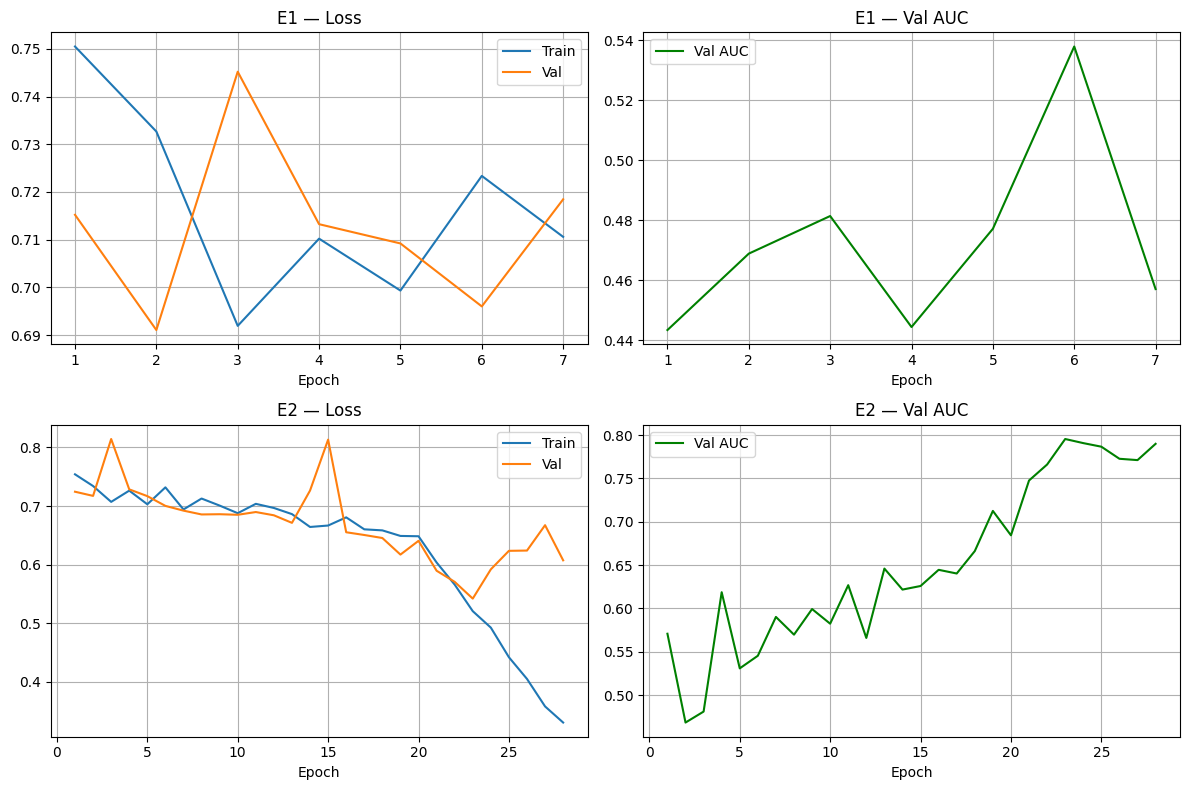

In [2]:
import matplotlib.pyplot as plt

if results:
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    for i, (name, r) in enumerate(sorted(results.items())):
        h = r['history']
        epochs = range(1, len(h['train_loss']) + 1)
        # Loss
        axes[i][0].plot(epochs, h['train_loss'], label='Train')
        axes[i][0].plot(epochs, h['val_loss'], label='Val')
        axes[i][0].set_title(f'{name} — Loss')
        axes[i][0].set_xlabel('Epoch')
        axes[i][0].legend()
        axes[i][0].grid(True)
        # AUC
        axes[i][1].plot(epochs, h['val_auc'], label='Val AUC', color='green')
        axes[i][1].set_title(f'{name} — Val AUC')
        axes[i][1].set_xlabel('Epoch')
        axes[i][1].legend()
        axes[i][1].grid(True)
    plt.tight_layout()
    plt.show()

### Confusion matrices & ROC curves

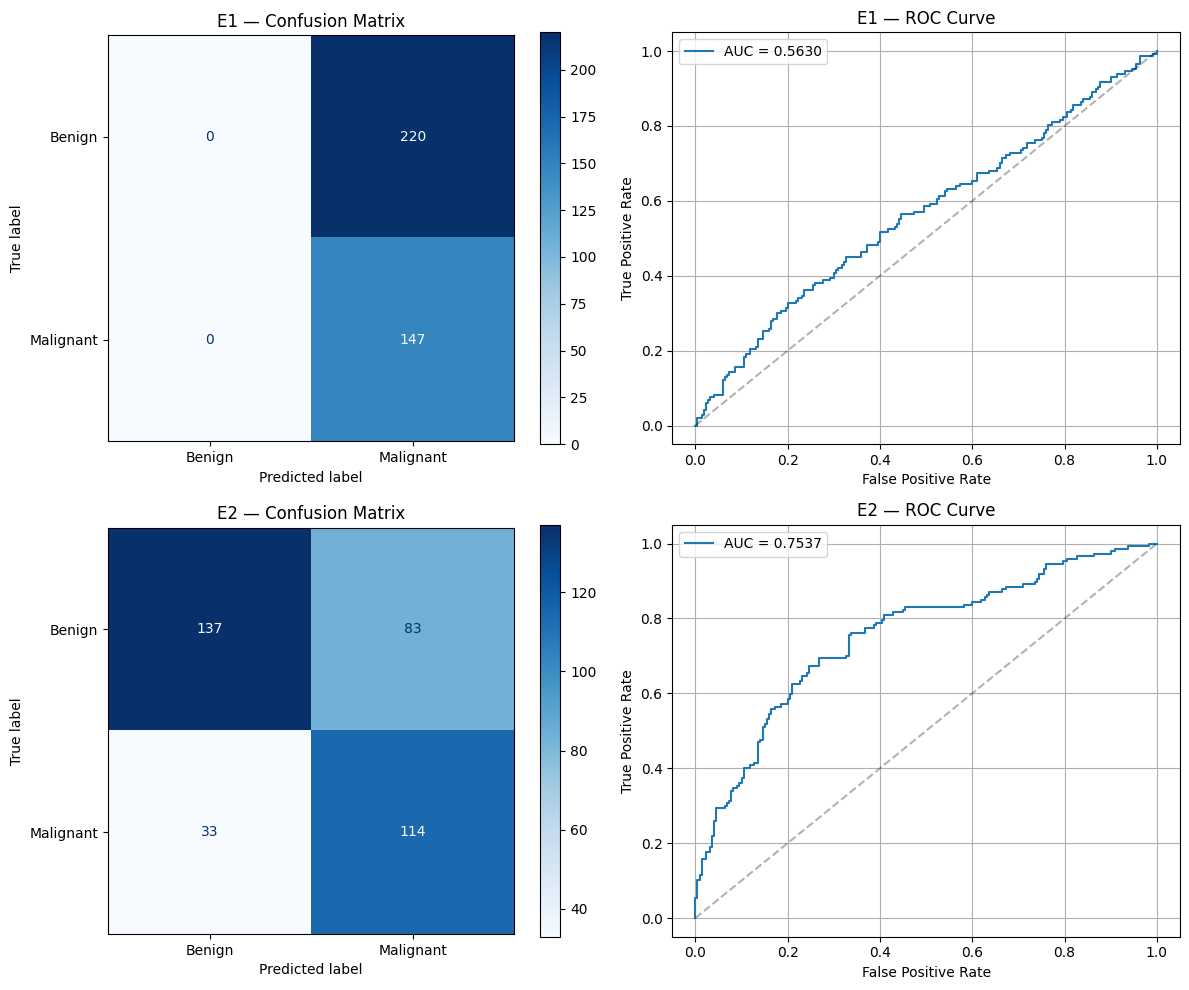

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

if results:
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n), squeeze=False)
    for i, (name, r) in enumerate(sorted(results.items())):
        if 'y_true' not in r:
            axes[i][0].set_title(f'{name} — no predictions saved')
            continue
        y_true = np.array(r['y_true'])
        y_prob = np.array(r['y_prob'])
        y_pred = (y_prob > 0.5).astype(int)
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=axes[i][0], cmap='Blues')
        axes[i][0].set_title(f'{name} — Confusion Matrix')
        # ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[i][1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
        axes[i][1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[i][1].set_title(f'{name} — ROC Curve')
        axes[i][1].set_xlabel('False Positive Rate')
        axes[i][1].set_ylabel('True Positive Rate')
        axes[i][1].legend()
        axes[i][1].grid(True)
    plt.tight_layout()
    plt.show()